# Ceteris paribus profiles — module 01

Molnar, *Interpretable Machine Learning*, **chapter 12**.

A ceteris paribus profile is the simplest question you can ask a model:
*hold everything about this patient fixed, move one measurement, and watch
the prediction*. It needs no surrogate, no sampling, no kernel. One feature,
one grid, one curve.

It is also the first place in this course where the model is asked about
patients who do not exist — and this notebook measures how much of the curve
is made of them.

The model, the split, the seed and the patient are **identical to module 03**,
so the four modules can be read as one continuous case.

In [1]:
%pip install -q scikit-learn matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

RANDOM_STATE = 42
BLUE = "#315B86"        # benign
TERRACOTTA = "#C96F3F"  # malignant
DARK = "#252525"
GRAY = "#A8A8A8"

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11, "figure.dpi": 140})

## The model, and the patient

Same as module 03, deliberately: a 300-tree RandomForest on the Breast Cancer
Wisconsin data, and test patient #67, who sits close to the decision boundary
at P(benign) = 0.581.

In [3]:
data = load_breast_cancer()
X_all, y_all = data.data, data.target
feature_names = list(data.feature_names)
class_names = list(data.target_names)  # ['malignant', 'benign']
feat_idx = {f: i for i, f in enumerate(feature_names)}

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=RANDOM_STATE, stratify=y_all
)
model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

proba_test = model.predict_proba(X_test)[:, 1]
test_acc = accuracy_score(y_test, model.predict(X_test))
test_auc = roc_auc_score(y_test, proba_test)

instance_idx = 67
row = X_test[instance_idx]
row_proba = proba_test[instance_idx]

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

print(f"patient #{instance_idx}: P(benign) = {row_proba:.3f}   "
      f"predicted {class_names[int(row_proba >= 0.5)]}, truly {class_names[y_test[instance_idx]]}")
print(f"model: test accuracy {test_acc:.1%}, ROC-AUC {test_auc:.3f}   "
      f"({len(X_train)} train / {len(X_test)} test)")

patient #67: P(benign) = 0.581   predicted benign, truly benign
model: test accuracy 95.1%, ROC-AUC 0.993   (426 train / 143 test)


## The definition, and the one line of code it takes

For feature $j$, a grid $z_1 \dots z_k$, and instance $\mathbf{x}$:

$$\text{CP}_j(z) = \hat{f}\big(z, \mathbf{x}_{-j}\big)$$

Everything except $x_j$ stays at this patient's values. That is the whole
method. The interesting part is not the computation — it is what those
manufactured rows are.

In [4]:
FIG_DIR = "figures_generated"  # regenerated on each run; committed copies live in ../figures
os.makedirs(FIG_DIR, exist_ok=True)


def cp_profile(base_row, j, grid):
    """f along a grid of feature j, everything else frozen at base_row."""
    probe = np.tile(base_row, (len(grid), 1))
    probe[:, j] = grid
    return model.predict_proba(probe)[:, 1]


def feature_grid(j, span=2.5, n=200):
    """An equidistant grid, ±span sigma around the patient, clipped to the
    range the feature actually takes in the full dataset."""
    lo = max(X_all[:, j].min(), row[j] - span * train_std[j])
    hi = min(X_all[:, j].max(), row[j] + span * train_std[j])
    return np.linspace(lo, hi, n)


def save_figure(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=200, bbox_inches="tight")


def new_figure(title, figsize=(8.5, 5.2)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", pad=12)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    return fig, ax

## Step 1 — one profile

`worst perimeter` is the feature LIME ranks first for this patient in module
03, so it is the natural one to sweep.

**What to look for.** The curve is a *staircase*, not a slope. A forest is
piecewise constant: it can only change its mind when a split is crossed. The
steps are where the model's answer actually lives; between them, moving the
measurement does nothing at all.

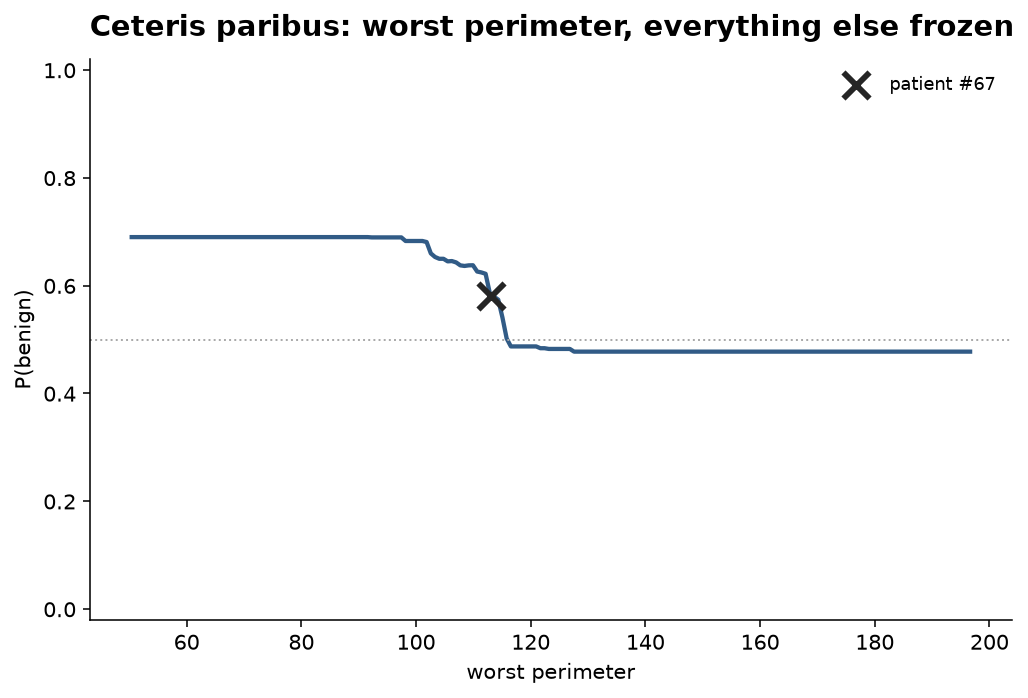

the grid: 200 points from 50.4 to 196.6, i.e. -1.88σ to +2.50σ around her value
  (we asked for ±2.5σ; the low end is clipped to the smallest worst
   perimeter in the data, so the sweep is not symmetric — say so when
   you quote the width)
the curve spans P = 0.478 to 0.690  (a swing of 0.212)
steps larger than 0.01: 6 of 199 grid intervals
the largest single step is 0.039, between worst perimeter 115.1 and 115.8
  (quoted below by the left edge of that interval, 115.1)


In [5]:
J = feat_idx["worst perimeter"]
grid = feature_grid(J)
prof = cp_profile(row, J, grid)

fig, ax = new_figure("Ceteris paribus: worst perimeter, everything else frozen")
ax.plot(grid, prof, color=BLUE, linewidth=2.2)
ax.axhline(0.5, color=GRAY, linewidth=1.0, linestyle=":")
ax.scatter([row[J]], [row_proba], s=180, marker="x", color=DARK, linewidths=3.0,
           zorder=10, label=f"patient #{instance_idx}")
ax.set_xlabel("worst perimeter")
ax.set_ylabel("P(benign)")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="upper right", fontsize=9.5, framealpha=0.93, edgecolor="none")
save_figure(fig, "cp_step_1_profile")
plt.show()

steps = np.abs(np.diff(prof))
big = steps > 0.01
k_step = int(np.argmax(steps))
print(f"the grid: {len(grid)} points from {grid[0]:.1f} to {grid[-1]:.1f}, i.e. "
      f"{(grid[0] - row[J]) / train_std[J]:+.2f}σ to "
      f"{(grid[-1] - row[J]) / train_std[J]:+.2f}σ around her value")
print("  (we asked for ±2.5σ; the low end is clipped to the smallest worst")
print("   perimeter in the data, so the sweep is not symmetric — say so when")
print("   you quote the width)")
print(f"the curve spans P = {prof.min():.3f} to {prof.max():.3f}  "
      f"(a swing of {prof.max() - prof.min():.3f})")
print(f"steps larger than 0.01: {big.sum()} of {len(steps)} grid intervals")
print(f"the largest single step is {steps.max():.3f}, between worst perimeter "
      f"{grid[k_step]:.1f} and {grid[k_step + 1]:.1f}")
print(f"  (quoted below by the left edge of that interval, {grid[k_step]:.1f})")

## Step 2 — how many of those rows could exist?

Module 03 measured the constraint we need: across all 569 real patients, the
ratio `worst perimeter / worst radius` stays between **6.22 and 7.67**.

Be precise about what that is. Perimeter over radius is **dimensionless** — a
shape factor — so unlike a ratio with units it does not drift with tumour
size, and a convex closed contour has a floor at $2\pi \approx 6.283$. But the
band itself is measured, not derived: its upper edge is a sample maximum over
569 patients, and the sample floor of 6.224 actually sits *below* $2\pi$.

The tempting explanation for that is order statistics — `worst X` is the mean
of the three largest values across nuclei, so the perimeter and the radius
need not come from the same nucleus. The cell after the plot falsifies it: the
`mean` block, where both columns average the *same* nuclei, dips *further* below the
floor. What is really going on is measurement. The perimeter is traced on a
digitised contour rather than on a smooth curve, so it is not the perimeter of
the disc its "radius" describes, and $2\pi$ is the right idea at the wrong
precision.

So this is an **empirical dependence envelope with a geometric floor**, not a
law. It is still the right instrument; it just should not be oversold.

The sweep above moves the perimeter while **freezing the radius**. So it
drives that ratio wherever it likes.

**What to look for.** The shaded band is the part of the x-axis where the
resulting patient is geometrically possible. Everything outside it is a
tumour that cannot be built.

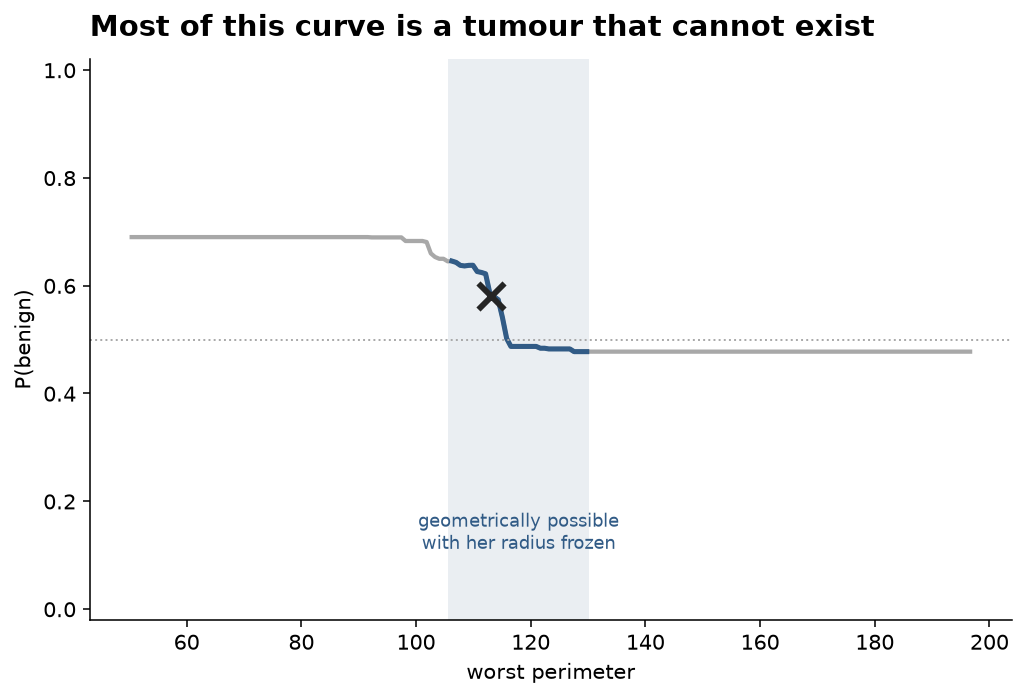

real perimeter/radius ratio, all 569 patients: 6.22 to 7.67   (2*pi = 6.283; the sample floor is below it)
her worst radius is frozen at 16.97, so the perimeter can only run 105.6 to 130.2
of the 200 grid points plotted, 167 (84%) are impossible patients
  same sweep, 1st-99th percentile band instead of min/max: 88%
  min/max band, sweep at +/-1 sigma instead of +/-2.5: 64%
  min/max band, sweep over the feature's full observed range (50 to 251): 88%

and the decisive question: the largest step sits at 115.1, INSIDE the possible range
  so the headline of this plot survives — what the model does where this
  patient could actually be is the same thing the full curve showed.
  That is a result about this feature, not a guarantee. Check it every time.


In [6]:
R = feat_idx["worst radius"]
ratio_real = X_all[:, feat_idx["worst perimeter"]] / X_all[:, R]
lo_ratio, hi_ratio = ratio_real.min(), ratio_real.max()

# with the radius frozen at hers, the perimeter can only live in this interval
poss_lo, poss_hi = lo_ratio * row[R], hi_ratio * row[R]
possible = (grid >= poss_lo) & (grid <= poss_hi)

fig, ax = new_figure("Most of this curve is a tumour that cannot exist")
ax.axvspan(poss_lo, poss_hi, color=BLUE, alpha=0.10, lw=0)
ax.plot(grid, prof, color=GRAY, linewidth=2.2)
ax.plot(grid[possible], prof[possible], color=BLUE, linewidth=2.6)
ax.axhline(0.5, color=GRAY, linewidth=1.0, linestyle=":")
ax.scatter([row[J]], [row_proba], s=180, marker="x", color=DARK, linewidths=3.0, zorder=10)
ax.annotate("geometrically possible\nwith her radius frozen",
            xy=((poss_lo + poss_hi) / 2, 0.10), ha="center", va="bottom",
            fontsize=9.5, color=BLUE)
ax.set_xlabel("worst perimeter")
ax.set_ylabel("P(benign)")
ax.set_ylim(-0.02, 1.02)
save_figure(fig, "cp_step_2_impossible")
plt.show()

print(f"real perimeter/radius ratio, all 569 patients: {lo_ratio:.2f} to {hi_ratio:.2f}"
      f"   (2*pi = {2 * np.pi:.3f}; the sample floor is below it)")
print(f"her worst radius is frozen at {row[R]:.2f}, so the perimeter can only run "
      f"{poss_lo:.1f} to {poss_hi:.1f}")
print(f"of the {len(grid)} grid points plotted, {(~possible).sum()} "
      f"({(~possible).mean():.0%}) are impossible patients")

# a tolerance interval is the defensible version of "the band", and it does not
# flatter us: the answer gets larger, not smaller
tol_lo, tol_hi = np.percentile(ratio_real, [1, 99])
tol_possible = (grid >= tol_lo * row[R]) & (grid <= tol_hi * row[R])
print(f"  same sweep, 1st-99th percentile band instead of min/max: "
      f"{(~tol_possible).mean():.0%}")

# the fraction is conditional on the sweep width, which is ours to choose. two
# different quantities land on the same rounded number, so keep them apart.
g_1sig = feature_grid(J, span=1.0)
g_full = np.linspace(X_all[:, J].min(), X_all[:, J].max(), len(grid))
print(f"  min/max band, sweep at +/-1 sigma instead of +/-2.5: "
      f"{(~((g_1sig >= poss_lo) & (g_1sig <= poss_hi))).mean():.0%}")
print(f"  min/max band, sweep over the feature's full observed range "
      f"({X_all[:, J].min():.0f} to {X_all[:, J].max():.0f}): "
      f"{(~((g_full >= poss_lo) & (g_full <= poss_hi))).mean():.0%}")

step_at = grid[np.argmax(steps)]
inside = poss_lo <= step_at <= poss_hi
print(f"\nand the decisive question: the largest step sits at {step_at:.1f}, "
      f"{'INSIDE' if inside else 'OUTSIDE'} the possible range")
print("  so the headline of this plot survives — what the model does where this")
print("  patient could actually be is the same thing the full curve showed.")
print("  That is a result about this feature, not a guarantee. Check it every time.")

In [7]:
# Why does the sample floor sit below 2*pi? The order-statistic story says
# `worst X` averages the three largest nuclei, so perimeter and radius may come
# from different ones. Test it on the `mean` block, where both columns average
# the SAME nuclei and that story cannot apply.
for a, b in [("worst perimeter", "worst radius"), ("mean perimeter", "mean radius")]:
    r = X_all[:, feat_idx[a]] / X_all[:, feat_idx[b]]
    print(f"{a:>15} / {b:<14}  min {r.min():.3f}   below 2*pi: "
          f"{(r < 2 * np.pi).sum():>2} of {len(r)}")
print(f"{'2*pi':>15}   {'':<14}      {2 * np.pi:.3f}")
print("\nThe mean block violates the floor too, and by more. So the cause is not")
print("mismatched nuclei: it is measurement. These perimeters are traced on a")
print("digitised contour, not on a smooth curve, so the perimeter is not the")
print("perimeter of the disc its radius describes. 2*pi is the right idea at the")
print("wrong precision — which is exactly why the band is called empirical.")

worst perimeter / worst radius    min 6.224   below 2*pi: 11 of 569
 mean perimeter / mean radius     min 6.175   below 2*pi:  6 of 569
           2*pi                       6.283

The mean block violates the floor too, and by more. So the cause is not
mismatched nuclei: it is measurement. These perimeters are traced on a
digitised contour, not on a smooth curve, so the perimeter is not the
perimeter of the disc its radius describes. 2*pi is the right idea at the
wrong precision — which is exactly why the band is called empirical.


## Step 3 — the check most people would run, and what it takes to make it work

The envelope above needed a physical fact about two columns. Most datasets
give no such gift, so the obvious substitute is distance: is the manufactured
row further from the data than real patients are from each other?

**Run it wrong first, because the wrong version is the one people run.**

In [8]:
Z_all = (X_all - train_mean) / train_std
probe = np.tile(row, (len(grid), 1))
probe[:, J] = grid
Zs = (probe - train_mean) / train_std

D_real = np.linalg.norm(Z_all[:, None, :] - Z_all[None, :, :], axis=2)
np.fill_diagonal(D_real, np.inf)
nn_real = D_real.min(axis=1)
yardstick = np.percentile(nn_real, 95)

D_naive = np.linalg.norm(Zs[:, None, :] - Z_all[None, :, :], axis=2)
nn_naive = D_naive.min(axis=1)

print(f"euclidean nearest-neighbour test, as usually written:")
print(f"  real patients sit within {yardstick:.2f} sigma of a neighbour (95th pct)")
print(f"  the sweep never exceeds {nn_naive.max():.2f} sigma")
print(f"  -> rejects {(nn_naive > yardstick).mean():.0%} of a curve the envelope rejects "
      f"{(~possible).mean():.0%} of")

euclidean nearest-neighbour test, as usually written:
  real patients sit within 4.45 sigma of a neighbour (95th pct)
  the sweep never exceeds 2.50 sigma
  -> rejects 0% of a curve the envelope rejects 84% of


**That 0% is worthless, and here is why.** The patient is herself a row of
`X_all`. Every point on the sweep therefore has *her* as its nearest "real"
neighbour, so the distance being measured is just the displacement along the
swept axis — and its maximum is the `span` we chose. The test was arithmetic,
not evidence.

In [9]:
self_idx = int(np.where(np.all(np.isclose(X_all, row), axis=1))[0][0])
print(f"the patient is X_all[{self_idx}], and she is in the reference set")
print(f"  she is the nearest neighbour at {(D_naive.argmin(axis=1) == self_idx).mean():.0%} "
      f"of the {len(grid)} grid points")
print(f"  max sweep distance {nn_naive.max():.3f} sigma == the span we set, "
      f"{np.abs(grid - row[J]).max() / train_std[J]:.3f} sigma")
print(f"  so with any span below {yardstick:.2f} sigma the test cannot fire at all")

Z_loo = np.delete(Z_all, self_idx, axis=0)
nn_loo = np.linalg.norm(Zs[:, None, :] - Z_loo[None, :, :], axis=2).min(axis=1)
print(f"\nleaving her out of the reference set, the sweep runs "
      f"{nn_loo.min():.2f} to {nn_loo.max():.2f} sigma, and the verdict depends "
      f"entirely on the cutoff:")
for q in (50, 75, 95):
    print(f"  vs the {q}th percentile of real distances "
          f"({np.percentile(nn_real, q):.2f} sigma): rejects "
          f"{(nn_loo > np.percentile(nn_real, q)).mean():.0%}")

the patient is X_all[375], and she is in the reference set
  she is the nearest neighbour at 100% of the 200 grid points
  max sweep distance 2.500 sigma == the span we set, 2.500 sigma
  so with any span below 4.45 sigma the test cannot fire at all

leaving her out of the reference set, the sweep runs 2.13 to 3.32 sigma, and the verdict depends entirely on the cutoff:
  vs the 50th percentile of real distances (2.07 sigma): rejects 100%
  vs the 75th percentile of real distances (2.69 sigma): rejects 21%
  vs the 95th percentile of real distances (4.45 sigma): rejects 0%


## Step 3b — the distance that does work

The euclidean test fails for a reason worth more than the test: it weights all
30 directions equally, and the sweep moves almost entirely *along* the data's
dominant correlated direction. A distance that knows the covariance does not
make that mistake.

**What to look for.** Mahalanobis recovers almost the whole envelope verdict,
knowing nothing about perimeters or radii.

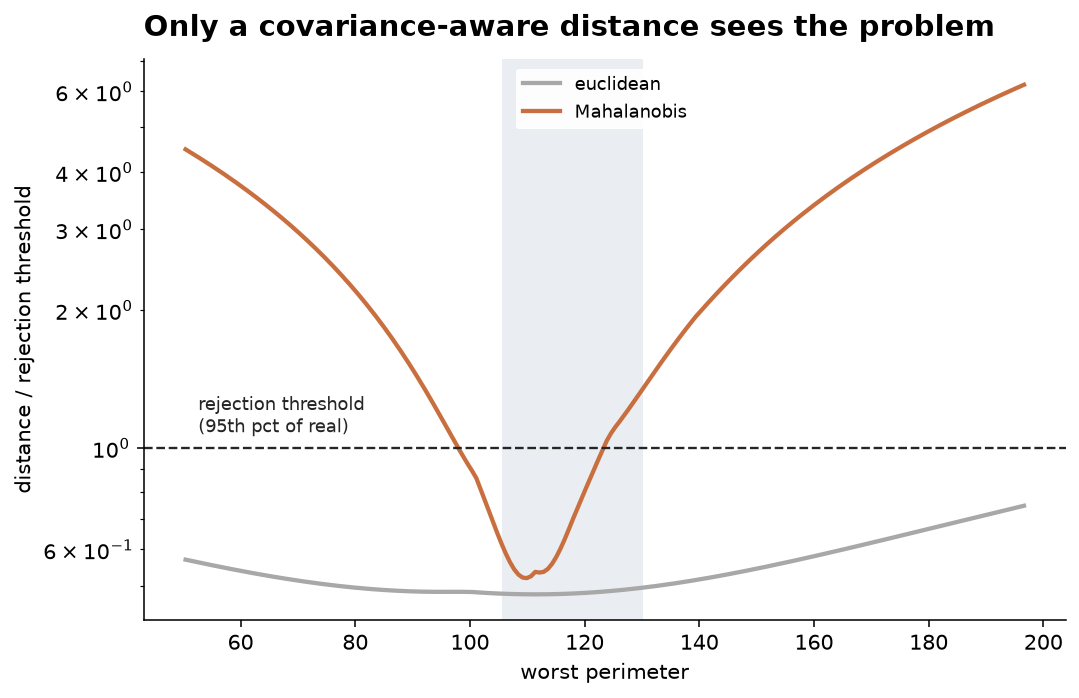

test                                rejects
euclidean NN (leave-one-out)            0%
Mahalanobis NN                         82%
the dependence envelope                84%

the counts are close, the SETS are not: the two verdicts agree at 90% of
the 200 grid points — 9 points Mahalanobis rejects and the envelope keeps, 11 the
other way round (the visible gaps between the two curves above). Same order
of magnitude from two unrelated criteria is the result; identity is not.

The lesson is not 'you need domain knowledge'. It is **marginal versus
conditional**. A ceteris paribus row is unremarkable under every feature's
own marginal distribution and absurd under their joint one. A metric
standardised per feature only sees the marginals; a whitened metric sees
the joint, and so does the envelope. Pick a tool that looks at the joint
and the problem is visible without knowing any anatomy.

This is also why module 03's attack works: Slack et al. (2020) hide a
classifier from LIME precisely be

In [10]:
VI = np.linalg.pinv(np.cov(Z_all.T))


def mahalanobis_nn(A, B):
    diff = A[:, None, :] - B[None, :, :]
    return np.sqrt(np.einsum("ijk,kl,ijl->ij", diff, VI, diff)).min(axis=1)


Dm = np.sqrt(np.einsum("ijk,kl,ijl->ij",
                       Z_all[:, None, :] - Z_all[None, :, :], VI,
                       Z_all[:, None, :] - Z_all[None, :, :]))
np.fill_diagonal(Dm, np.inf)
mh_real = Dm.min(axis=1)
mh_sweep = mahalanobis_nn(Zs, Z_loo)
mh_cut = np.percentile(mh_real, 95)

fig, ax = new_figure("Only a covariance-aware distance sees the problem")
ax.plot(grid, nn_loo / yardstick, color=GRAY, linewidth=2.2, label="euclidean")
ax.plot(grid, mh_sweep / mh_cut, color=TERRACOTTA, linewidth=2.2, label="Mahalanobis")
ax.axhline(1.0, color=DARK, linewidth=1.2, linestyle="--")
ax.annotate("rejection threshold\n(95th pct of real)", xy=(grid[3], 1.0),
            xytext=(0, 8), textcoords="offset points", fontsize=9.5, color=DARK)
ax.axvspan(poss_lo, poss_hi, color=BLUE, alpha=0.10, lw=0)
ax.set_xlabel("worst perimeter")
ax.set_ylabel("distance / rejection threshold")
ax.set_yscale("log")
ax.legend(loc="upper center", fontsize=9.5, framealpha=0.93, edgecolor="none")
save_figure(fig, "cp_step_3_distance")
plt.show()

print(f"{'test':<34} {'rejects':>8}")
print(f"{'euclidean NN (leave-one-out)':<34} {(nn_loo > yardstick).mean():>7.0%}")
print(f"{'Mahalanobis NN':<34} {(mh_sweep > mh_cut).mean():>7.0%}")
print(f"{'the dependence envelope':<34} {(~possible).mean():>7.0%}")

# the two counts nearly match; the two verdicts do not name the same points
mh_rejects = mh_sweep > mh_cut
print(f"\nthe counts are close, the SETS are not: the two verdicts agree at "
      f"{(mh_rejects == ~possible).mean():.0%} of")
print(f"the {len(grid)} grid points — {(mh_rejects & possible).sum()} points Mahalanobis rejects and the envelope keeps, "
      f"{(~mh_rejects & ~possible).sum()} the")
print("other way round (the visible gaps between the two curves above). Same order")
print("of magnitude from two unrelated criteria is the result; identity is not.")

print("\nThe lesson is not 'you need domain knowledge'. It is **marginal versus")
print("conditional**. A ceteris paribus row is unremarkable under every feature's")
print("own marginal distribution and absurd under their joint one. A metric")
print("standardised per feature only sees the marginals; a whitened metric sees")
print("the joint, and so does the envelope. Pick a tool that looks at the joint")
print("and the problem is visible without knowing any anatomy.")
print("\nThis is also why module 03's attack works: Slack et al. (2020) hide a")
print("classifier from LIME precisely because LIME's perturbations ARE detectable")
print("as out-of-distribution by a model that looks at the joint.")

## Step 4 — the remedy the book proposes, tested

Molnar's advice for correlated features, quoted properly this time:

> "This can be alleviated by e.g. restricting the range of the ceteris paribus
> plots to shorter ranges, at least for correlated features. But this would
> also mean we need a model or procedure to tell us what these ranges are."

The second sentence is the one that matters, and the envelope above **is**
such a procedure. So this section is not just applying his advice — it is
supplying the missing piece he flags.

So restrict it. Keep only the part of the sweep that is geometrically
possible, and ask what is left of the story.

**What to look for.** Whether the restricted curve still says what the full
one said. If the interesting behaviour was in the discarded part, the remedy
does not rescue the plot — it deletes it. Here it is cheap: most of the swing
is inside the realistic interval and the crossing of P = 0.5 survives. That is
a fact about this feature, and the reason to run the check rather than assume
either outcome.

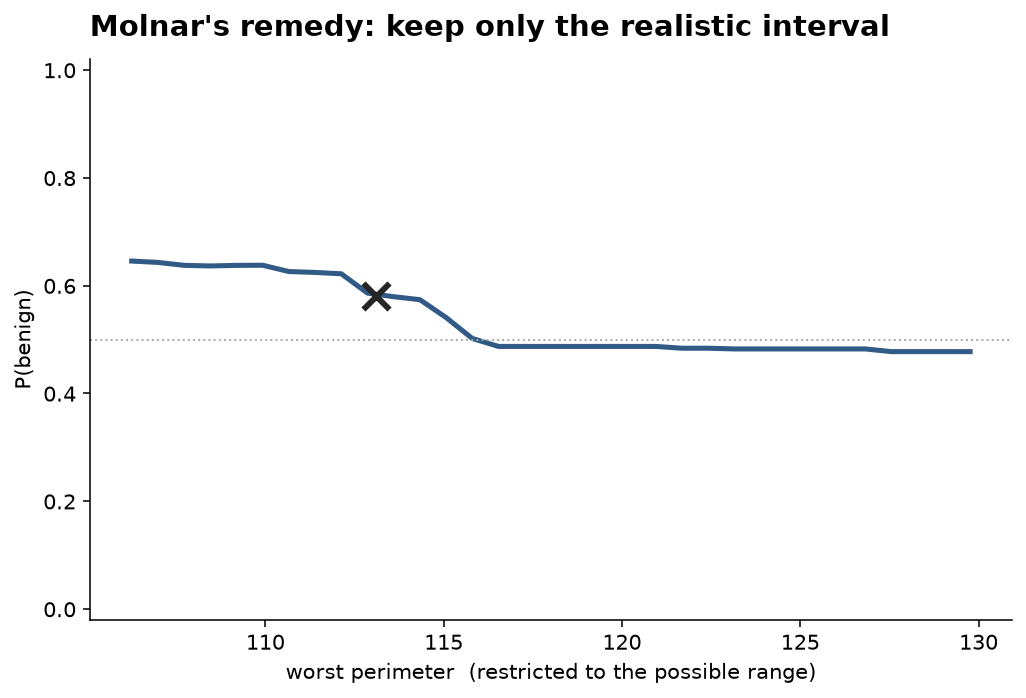

swing in P:      full sweep 0.212   restricted 0.168   (79% survives)
crosses P=0.5:   full sweep True   restricted True


In [11]:
fig, ax = new_figure("Molnar's remedy: keep only the realistic interval")
ax.plot(grid[possible], prof[possible], color=BLUE, linewidth=2.6)
ax.axhline(0.5, color=GRAY, linewidth=1.0, linestyle=":")
ax.scatter([row[J]], [row_proba], s=180, marker="x", color=DARK, linewidths=3.0, zorder=10)
ax.set_xlabel("worst perimeter  (restricted to the possible range)")
ax.set_ylabel("P(benign)")
ax.set_ylim(-0.02, 1.02)
save_figure(fig, "cp_step_4_restricted")
plt.show()

swing_full = prof.max() - prof.min()
swing_rest = prof[possible].max() - prof[possible].min()
crosses_full = np.any(prof >= 0.5) and np.any(prof < 0.5)
crosses_rest = np.any(prof[possible] >= 0.5) and np.any(prof[possible] < 0.5)
print(f"swing in P:      full sweep {swing_full:.3f}   restricted {swing_rest:.3f}   "
      f"({swing_rest / swing_full:.0%} survives)")
print(f"crosses P=0.5:   full sweep {crosses_full}   restricted {crosses_rest}")

## The same measurement, across her strongest features

One feature could be a special case. Here are the six the forest leans on
most, each swept the same way, each with its possible range shaded.

**What to look for.** The impossible fraction is not a quirk of perimeter. It
is what the method does.

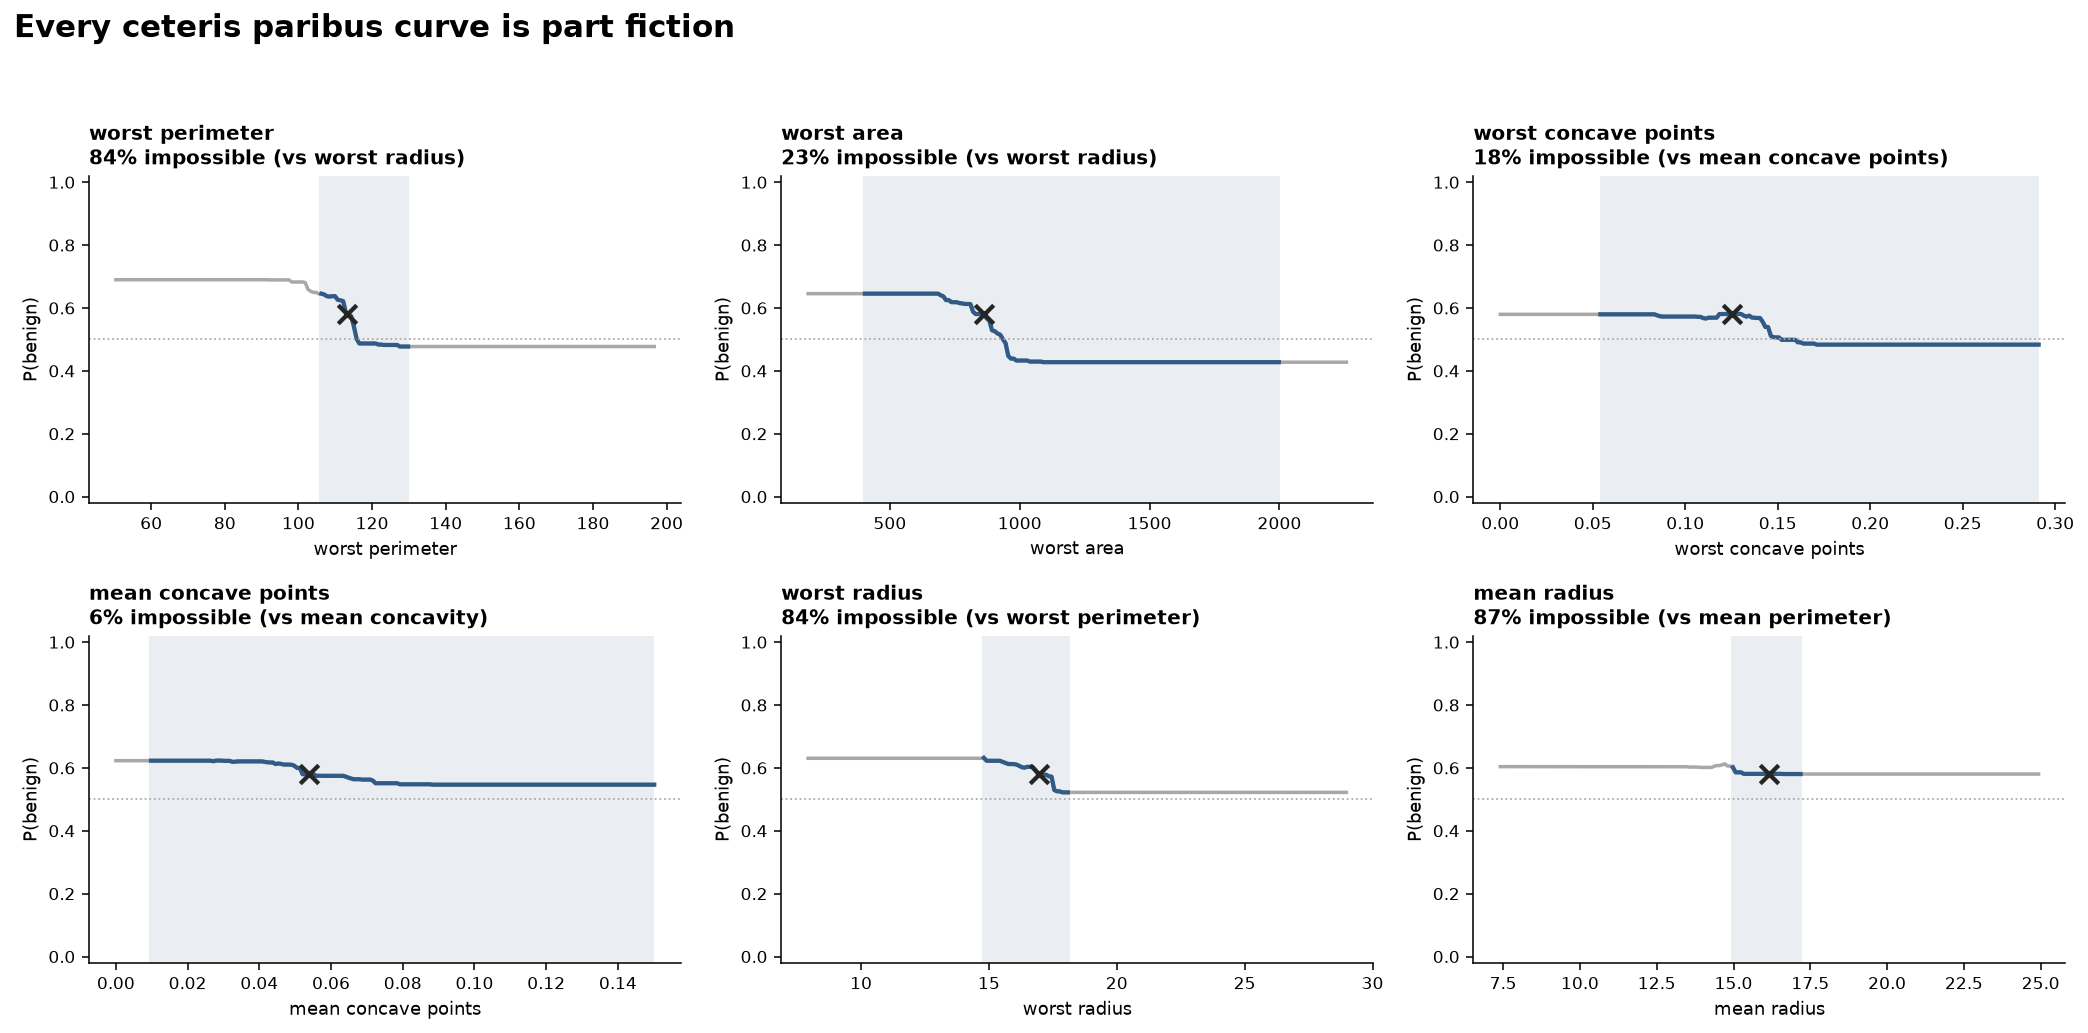

feature                     impossible  swing in P
worst perimeter                   84%       0.212
worst area                        23%       0.218
worst concave points              18%       0.098
mean concave points                6%       0.077
worst radius                      84%       0.110
mean radius                       87%       0.032

median impossible fraction over the six: 53%


In [12]:
top6 = np.argsort(-model.feature_importances_)[:6]
partner = {}
for j in top6:
    # the training-set feature most correlated with j is the one being violated
    c = np.abs([np.corrcoef(X_train[:, j], X_train[:, k])[0, 1] if k != j else 0
                for k in range(len(feature_names))])
    partner[j] = int(np.argmax(c))

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
summary = []
for ax, j in zip(axes.ravel(), top6):
    g = feature_grid(j)
    p = cp_profile(row, j, g)
    k = partner[j]
    r_real = X_all[:, j] / np.where(X_all[:, k] == 0, np.nan, X_all[:, k])
    lo_r, hi_r = np.nanmin(r_real), np.nanmax(r_real)
    ok = (g >= lo_r * row[k]) & (g <= hi_r * row[k]) if row[k] != 0 else np.ones_like(g, bool)
    # shade the true interval, as the single-feature plot above does — the extent
    # of the grid points inside it is up to one spacing narrower on each side
    band_lo = max(lo_r * row[k], g[0]) if row[k] != 0 else g[0]
    band_hi = min(hi_r * row[k], g[-1]) if row[k] != 0 else g[-1]
    if band_hi > band_lo:
        ax.axvspan(band_lo, band_hi, color=BLUE, alpha=0.10, lw=0)
    ax.plot(g, p, color=GRAY, linewidth=1.8)
    ax.plot(g[ok], p[ok], color=BLUE, linewidth=2.2)
    ax.axhline(0.5, color=GRAY, linewidth=0.9, linestyle=":")
    ax.scatter([row[j]], [row_proba], s=90, marker="x", color=DARK, linewidths=2.2, zorder=10)
    ax.set_title(f"{feature_names[j]}\n{(~ok).mean():.0%} impossible "
                 f"(vs {feature_names[k]})", loc="left", fontsize=10.5, fontweight="bold")
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel(feature_names[j], fontsize=9)
    ax.set_ylabel("P(benign)", fontsize=9)
    ax.tick_params(labelsize=8.5)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    summary.append((feature_names[j], (~ok).mean(), p.max() - p.min()))
fig.suptitle("Every ceteris paribus curve is part fiction", x=0.007, ha="left",
             fontsize=16, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_figure(fig, "cp_top_features")
plt.show()

print(f"{'feature':<26} {'impossible':>11} {'swing in P':>11}")
for name, frac, swing in summary:
    print(f"{name:<26} {frac:>10.0%} {swing:>11.3f}")
print(f"\nmedian impossible fraction over the six: "
      f"{np.median([f for _, f, _ in summary]):.0%}")

## What to carry to the next module

A ceteris paribus profile is honest about one thing and silent about another.

It is honest about **the model**: the staircase is exactly what the forest
does, computed and not sketched. Nothing is approximated, and there is no
surrogate standing between you and $\hat{f}$.

It is silent about **whether the question is meaningful**. Freezing 29
measurements while one moves builds patients that could not be biopsied — 84%
of the plotted curve on her strongest feature at the sweep width we chose,
and the six features the forest leans on most split into two clusters rather
than averaging: three at 6-23% and three at 84-87%.

And the check most people would reach for is the wrong one, twice over. Run
naively it cannot fire at all, because the patient is her own nearest
neighbour. Run properly but with a per-feature standardised metric it still
clears the sweep, because a one-feature move is small in 30 dimensions. A
covariance-aware metric catches it immediately.

The general statement is **marginal versus conditional**: these rows are
typical under every marginal and impossible under the joint. That is the
vocabulary the field uses, it is what accumulated local effects (Molnar
chapter 20) was designed to fix, and it is why the same perturbations are
detectable enough for Slack et al. (2020) to build an attack on them.

That is not a defect of the plot. It is the price of the *ceteris paribus*
clause itself, and every method in this course pays some version of it.

Prior art, since the outline treats this as the section's punchline: Goldstein
et al. (2015) §4.3, "Extrapolation Detection", makes exactly this point with a
generating process in which each coordinate is unremarkable and the
combination has probability zero. Their remedy — marking each curve at its
observed value so extrapolated segments are visible — is worth adopting.

Module 02 stacks these curves, one per patient, and asks what the average of
them hides.

In [13]:
print("Technical companion, with the LIME comparison: cp_internals.ipynb")

Technical companion, with the LIME comparison: cp_internals.ipynb
